In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

import random

In [ ]:
words = open('data/names.txt', 'r').read().splitlines()

# build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
vocab_size = len(chars) + 1
stoi = {ch: i+1 for i, ch in enumerate(chars)}  # string to index
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}  # index to string

# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [111]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True

    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var

    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta

    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  
  def parameters(self):
    return []
  

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
  
  def __call__(self, x):
    self.out = self.weight[x]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C  = x.shape
    # 4, 8, 10
    x = x.view(B, T // self.n, C * self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [113]:
torch.manual_seed(42)

In [134]:
n_embd = 24 # size of word embeddings
n_hidden = 128 # size of hidden layers

model = Sequential([
    Embedding(vocab_size, n_embd),
    
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False), # input layer
    BatchNorm1d(n_hidden), # batch normalization layer
    Tanh(),

    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), # input layer
    BatchNorm1d(n_hidden), # batch normalization layer
    Tanh(),

    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), # input layer
    BatchNorm1d(n_hidden), # batch normalization layer
    Tanh(),

    Linear(n_hidden, vocab_size)
])

# with torch.no_grad():
#     layers[-1].weight *= 0.1 # scale the output layer weights down

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters
for p in parameters:
    p.requires_grad = True # enable gradient tracking

76579


In [135]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
print("-----")
print(Xb)
print("-----")

for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

torch.Size([4, 8])
-----
tensor([[ 0,  0,  0,  0,  0, 10,  1, 26],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  3,  8],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])
-----
Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [136]:
max_steps = 100000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    # Update simple SGD
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    # Track
    if i % 2000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
    lossi.append(loss.log10().item())


      0/ 100000: 3.494796
   2000/ 100000: 2.394462
   4000/ 100000: 2.461562
   6000/ 100000: 1.827608
   8000/ 100000: 2.016880
  10000/ 100000: 2.023165
  12000/ 100000: 1.984303
  14000/ 100000: 1.766729
  16000/ 100000: 1.887687
  18000/ 100000: 1.508078
  20000/ 100000: 2.031699
  22000/ 100000: 1.841591
  24000/ 100000: 2.067447
  26000/ 100000: 2.076790
  28000/ 100000: 1.821826
  30000/ 100000: 1.959888
  32000/ 100000: 1.813191
  34000/ 100000: 2.014063
  36000/ 100000: 2.289762
  38000/ 100000: 1.546482
  40000/ 100000: 2.315769
  42000/ 100000: 1.923484
  44000/ 100000: 2.041432
  46000/ 100000: 1.764489
  48000/ 100000: 2.174111
  50000/ 100000: 1.763632
  52000/ 100000: 1.799806
  54000/ 100000: 2.146666
  56000/ 100000: 1.711141
  58000/ 100000: 1.920104
  60000/ 100000: 2.169234
  62000/ 100000: 1.760562
  64000/ 100000: 1.910118
  66000/ 100000: 1.763904
  68000/ 100000: 1.729774
  70000/ 100000: 1.991678
  72000/ 100000: 2.171221
  74000/ 100000: 2.161415
  76000/ 100

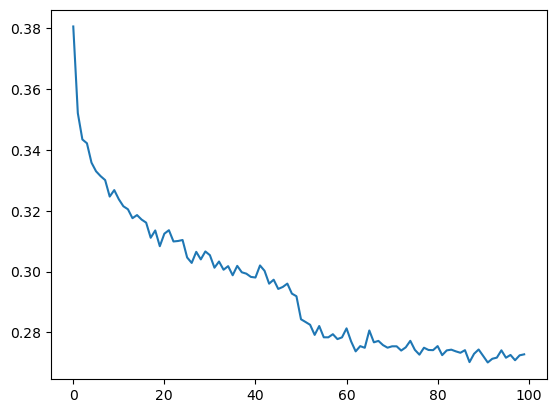

In [137]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(dim=1))

In [141]:
for layer in model.layers:
    layer.training = False

In [142]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    loss = F.cross_entropy(model(x), y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8540693521499634
val 1.9922959804534912


In [143]:
# Sample from the model.
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join([itos[i] for i in out]))

katalie.
tavius.
ahmari.
chame.
andriana.
hible.
nashhun.
saed.
eseyman.
araly.
blagan.
novaas.
harles.
caileigh.
araya.
korren.
ezaan.
viretra.
hondree.
jerry.
